# Day 15 In-Class: Weather Prediction

### <p style="text-align: right;"> &#9989; Put your name here.</p>

#### <p style="text-align: right;"> &#9989; Put your group member names here.</p>

<img src="https://www.lansingstatejournal.com/gcdn/presto/2018/10/20/PLSJ/0aceec7e-85b0-48d9-8e59-4b250eb7864f-181020_msu_um_111a.JPG?width=1320&height=882&fit=crop&format=pjpg&auto=webp" width=800px>

## Goals for today's in-class assignment

* Apply regression or autoregression model to model weather data and forecast future values.

## Assignment instructions

Work with your group to complete this assignment. Instructions for submitting this assignment are at the end of the notebook. The assignment is due at the end of class.

**Important**: The culmination of this assignment is to create the most accurate temperature prediction you can for the temperatures on October 31 (*the end of the month!*) along with an appealing visualization. You are welcome to work as a group to submit your best possible prediction!

---
# Forecasting Weather Trends in Lansing

## Background

In this activity you will extend your skills as a data scientist from understanding the past to predicting the future. Because of its impact on our daily lives and its potential [enormous consequences for the future of our civilization](https://www.nytimes.com/interactive/2016/08/20/sunday-review/climate-change-hot-future.html), we will use weather data.

There is an abundance of data on this subject available freely on the Internet. We'll load the data into this notebook using Pandas. The data you're using have been extracted from the National Centers for Environmental Information from NOAA (https://www.ncdc.noaa.gov/cdo-web/) for the Lansing weather station located at the airport (USW00014836).  Once you load in the data, we will model it. The models we will use are very simple: looking at trends by assuming the data have some functional form (here, we assume it follows a polynomial).

You will also continue to build upon your experience using one of Scipy's built-in "black boxes" for finding trends in a set of numbers (temperature data in our case). That functionality is called __`curve_fit`__ and, provided you send it the information it wants in the form it wants, it will return to you the "best" fit for the data. Roughly speaking, "best" means that none of the data are too far away from the fit line. As before, you will need to understand exactly what it returns. As always, use the Internet to find any additional information you might need. 

Our goal for today is to both model _and_ forecast the weather in Lansing so for part of the assignment you predict future values using your model. You can use the last ~4+ years of data from to do this if you wish!

Let's get to it!

---
## Part 1. Loading and inspecting the data

On the class website you can find a dataset that contains weather data from the Lansing weather from Jan 1st, 2019 until Oct 5, 2023. The code below loads the dataset and transforms the data so that it is easier to handle for our regression task.

If you're interested in knowing how we got the data off of the web, talk to us after class!

&#9989; **Task** Download the file `NOAA_RawData_20231013.csv` from the class website and run the code below

In [1]:
# We'll load up some Python modules and set some parameters for making higher quality plots.
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [5]:
# Load up the data and make some plots of it to understand what some of the visual trends are
data = pd.read_csv("PATH TO THE DATASET")
# Print the columns to see what kind of data we have
print(data.columns)
# Display the first few rows
data.tail()

FileNotFoundError: [Errno 2] No such file or directory: 'PATH TO THE DATASET'

There is a lot of interesting information in this dataset: 
    
    WSF2 - Fastest 2-minute wind speed
    WDF2 - Direction of fastest 2-minute wind
    AWND - Average wind speed
    WSF5 - Fastest 5-second wind speed
    WDF5 - Direction of fastest 5-second wind
    SNOW - Snowfall
    PGTM - Peak gust time
    TMAX - Maximum temperature
    TAVG - Average Temperature.
    TMIN - Minimum temperature
    PRCP - Precipitation
    SNWD - Snow depth

But we are interested only in the time and temperature for this assignment. 


&#9989; **Task:** Run the code below and add your comments to the lines of code you don't understand. Then using `seaborn` make a scatter plot of the average temperature vs date only for the year 2023.

In [3]:
# There are too many columns. Let's keep only the ones we need.
data = data[["DATE", "TAVG", "TMIN", "TMAX"]]

# Transform the DATE column into a datetime format
data["DATE"] = pd.to_datetime(data["DATE"])

# Use a mask to select only year 2023
data_2023 = data[data['DATE'].dt.year == 2023]

# Calculate the number of days since Jan 1, 2023. 
# We will use TIME DELTA as the independent variable in our model
data_2023["TIME DELTA"] = (data_2023["DATE"] - data_2023["DATE"].iloc[0]).dt.days

data_2023.head()

# Put your plotting code here



/var/folders/lm/dn75vz_d72b1cntn3ncjj10c0000gn/T/ipykernel_5223/2058393866.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2023["TIME DELTA"] = (data_2023["DATE"] - data_2023["DATE"].iloc[0]).dt.days


,DATE,TAVG,TMIN,TMAX,TIME DELTA
1249,2023-01-01,2.9,0.6,7.2,0
1250,2023-01-02,3.4,1.1,5.6,1
1251,2023-01-03,3.7,2.2,6.7,2
1252,2023-01-04,6.2,2.2,7.8,3
1253,2023-01-05,2.4,0.6,3.3,4


Our goal is to use regression to predict the weather for the next two weeks. In order to do that we need to transform our data such that we can feed it to `curve_fit`

&#9989; **Task:** Run the code below and add your comments to the lines you don't understand. The code selects all the data prior to Sep 1, 2023 and after Sep 1, 2023 and puts them into two different dataframes.  We will use the first dataframe to fit our model and the second to test our model. 

In [5]:
# We will use this to fit our model
aug_mask = data_2023['DATE'].dt.month <9 
aug_2023 = data_2023[aug_mask]

# Select only the october data. We will use this to test our model
oct_mask = data_2023['DATE'].dt.month >= 9
oct_2023 = data_2023[oct_mask]

aug_2023.head()

,DATE,TAVG,TMIN,TMAX,TIME DELTA
1249,2023-01-01,2.9,0.6,7.2,0
1250,2023-01-02,3.4,1.1,5.6,1
1251,2023-01-03,3.7,2.2,6.7,2
1252,2023-01-04,6.2,2.2,7.8,3
1253,2023-01-05,2.4,0.6,3.3,4


---

## Part 2: Modeling weather data with regression

Let's think about how to model the weather. As you certainly have realized, this is an incredibly difficult thing to do. But, what we will do here is examine past data and use it to predict future trends. If we were looking at data over a fairly short time period (say January and February) and predicting March, we may only need to ask: how much is the temperature increasing or decreasing as we head into the early parts of spring? To do this, we could assume that there is a linear relationship with time, as in

$$ T(t) = \gamma t + \delta,$$

where $\gamma$ and $\delta$ can be obtained by looking at past data. But, you could argue: this model for the data is too simple, and we might instead try something like

$$ T(t) = \beta t^2 + \gamma t + \delta, $$

which has some curvature to it - it is a "quadratic" function (or, a "parabola" if you prefer to think in terms of its graph). We could even try a cubic model

$$ T(t) = \alpha t^3 + \beta t^2 + \gamma t + \delta,$$

The quadratic and cubic models are nice because they have more structure in it and one more parameter that can help us capture details in the data better. In general, functions like this are called "polynomials", and we could also consider a quartic (by adding yet another term with $t^4$). 

&#9989; **Task:** Use `curve_fit` to fit a quadratic function to the `aug_2023` dataset, which contains almost a full year of information and plot the best fit line along with the data. You're free to try fitting whichever temperature value you want (i.e. min, max, or mean). Then, try fitting a cubic function as well (i.e. one that uses $t^3$!). 

**Note:** Plotting code is already there you just need to add your fitted functions.

In [6]:
from scipy.optimize import curve_fit

def quadratic(x, a, b, c):
    return a * x**2 + b*x + c

def cubic(x, a, b, c, d):
    return a * x**3 + b*x**2 + c*x + d


ValueError: Could not interpret value `Whatever You Chose to Fit` for parameter `y`

<Figure size 800x600 with 0 Axes>

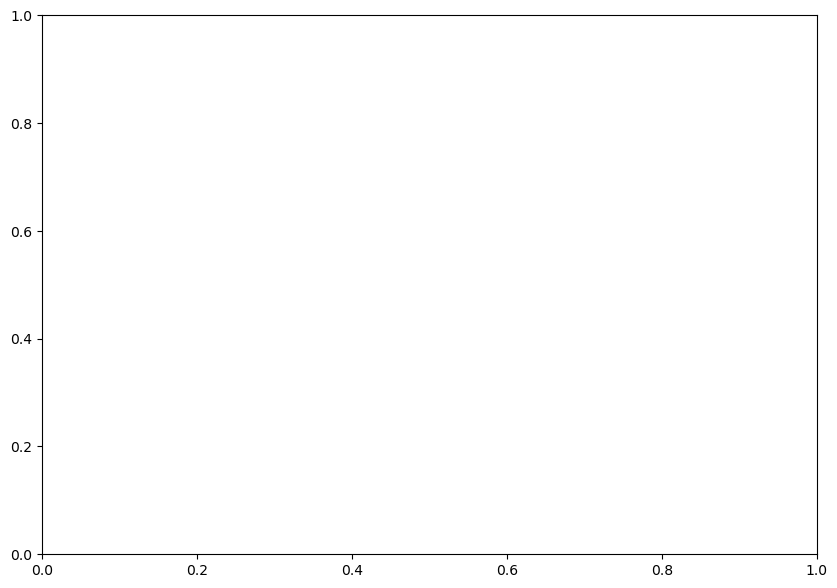

In [7]:
plt.figure(figsize=(8,6))

# Put your code for fitting here


fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.scatterplot(data = aug_2023, x = "TIME DELTA", y = "Whatever You Chose to Fit", s = 50, c = 'g', edgecolor = 'k', ax = ax)
ax.plot(aug_2023["TIME DELTA"], ... ,  lw = 2,  label = "Quadratic Fit")
ax.plot(aug_2023["TIME DELTA"], ... ,  lw = 2, label = "Cubic Fit")
ax.set( xlabel = 'Days since Jan 1st', ylabel = "Average Temperature [C]")
ax.legend()
ax.grid(alpha = 0.3)

&#9989; **Task:** Now take your fit and **extend it to predict the "future" data.** Then, add your prediciton to the plot below. What do you observe?

&#9989; **Question:** What do you notice?

<font size=+3>&#9998;</font> *Put your answers here*

---
## Part 3. Fitting weather data with autoregression

Intuitively, when we predict the tomorrow's temperature, we will usually use the information about today's temperature. This leads to a so-called **autoregression** model:
$$ T(t+1) = \beta T(t) + \gamma.$$

_An autoregressive model is one where a value from a time series is regressed on previous values from that same time series._

Now, let's make a plot visually checking the relationship between `TMAX(t)` and `TMAX(t + 1)`, which is the temperature of the day after the first one. Let's use the data from 2023. What type of plot should you choose? (Think back to the pre-class assignment)

In [11]:
# Put your plotting code here


&#9989; **Question:** Does it show strong a linear relationship? If so, how can we estimate it using `curve_fit`? 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


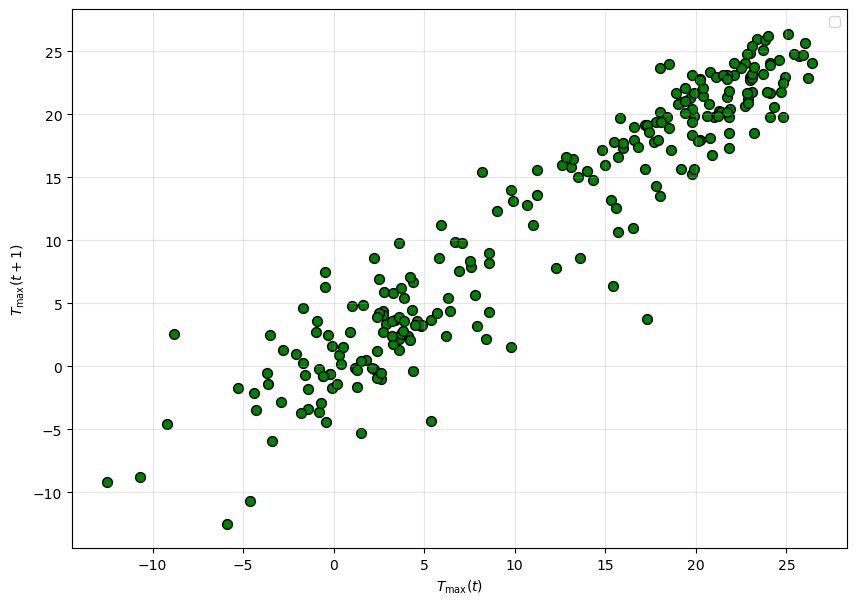

In [13]:
# Create your auto-regressive model with curve_fit here and plot the resulting fit

fig, ax = plt.subplots(1,1, figsize = (10,7))
lag_plot(aug_2023["TAVG"], ax = ax, s = 50, c = 'g', edgecolor = 'k')

# Plot your model here

ax.set( xlabel = r'$T_{\rm max}(t)$', ylabel = r'$T_{\rm max}(t + 1)$')
ax.legend()
ax.grid(alpha = 0.3)

Now, we can use the autoregressive model to make a prediction for the rest of October, using all of the data we have. 

&#9989; **Task:**  Using your autoregressive model make a prediction for the rest of the month

In [15]:
# Put your code here

&#9989; **Question**: How does your model compare to the data? How do you think you can improve your model? Try plotting the entire dataset, what do you notice?

<font size=+3>&#9998;</font> *Put your answers here*

<img src="http://www.azquotes.com/picture-quotes/quote-prediction-is-very-difficult-especially-if-it-s-about-the-future-niels-bohr-3-7-0757.jpg" width=600px>

---
##  Part 4: Looking for correlations in weather data (Time Permitting)

Next, we are going to revisit a very powerful idea, __correlations__ in data. When you have made plots so far, you plot the quantity of interest (e.g. temperature, position) against an obvious parameter, such as space $x$ or time $t$. The question we wish to answer now is: if we have two variables $T_1$ and $T_2$ that are both collected at various times $t$, are there relations between the values of $T_1$ and $T_2$ that hold for all $t$? That is, if we knew something about $T_1$, would be able to predict something about $T_2$? Such relationships would be incredible useful! This is a deep subject, and we will only scratch the surface here by making a plot.

Notice that Matplotlib will accept two arrays of the same length and plot the second versus the first. So, suppose we plot $T_1$ versus $T_2$. What would that look like? If there are correlations, when $T_1$ goes up, $T_2$ is likely to go up; that is, they might appear to fall along a line. Let's try it!

&#9989; **Task:** Using the code provided in Part 1, select **only data for 2022** and make **a scatter plot of the max temperatures versus the min temperatures**. You can use `seaborn` or `matplotlib` for this, your choice.

In [17]:
# Put your code here


The Python ecosystem has some amazing tools for performing computational modeling. We have already seen a few of these:
* NumPy
* Matplotlib
* Pandas
* Seaborn

Today, we will explore more about __Seaborn__. As always, if you want to learn more, you can go to its [website](http://seaborn.pydata.org/). There is a huge amount there, and we will only use a little of it today. As you progress through the semester, you can explore more of the things that Seaborn can help you with. Seaborn has a an impressive collection of special types of plots that are a bit different from the ordinary types you have learned earlier in the course (e.g. pie, histogram, line), and Seaborn's plots are well suited to data-science problems. 

Here is an simple example that uses the [jointplot](http://seaborn.pydata.org/generated/seaborn.jointplot.html) function in Seaborn to plot a correlation (for more information with what you can do with `jointplot` scroll through the documentation page in the link). **Pay special attention to the `kind` parameter, what happens if you don't include this?**

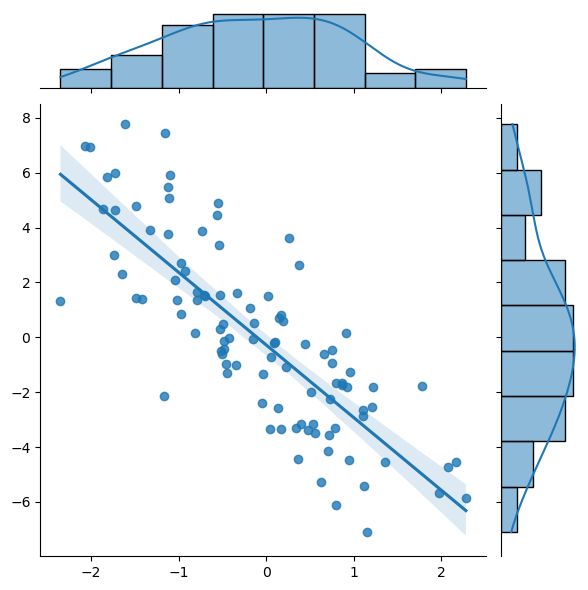

In [19]:
import numpy as np

x_fake = np.random.randn(100) #(1, 100)
y_fake = -3*x_fake +  2*np.random.randn(100) #(1, 100)
sns.jointplot(x=x_fake, y=y_fake, kind = 'reg')

&#9989; **Task:** Examine this plot carefully. **What types of information are immediately apparent to you? In what situation would you use plots of this type?**

<font size=+3>&#9998;</font> *Put your answers here*

Sometimes you will have many features in your data (highs, lows, averages, highest ever, lowest ever; lead, titanium, cromium, and so on.) [Click here](https://seaborn.pydata.org/generated/seaborn.pairplot.html) to see how Seaborn can be used to find correlations among several variables. These types of plots are [very much customizable](http://i.imgur.com/K3bUaas.png).

&#9989; **Task:** Remake your correlation plot for the 2022 data using Seaborn's `jointplot` function. Does it look like Seaborn was able to find a correlation? Then, **make a plot for the 2023 dataset.** Is the correlation similar?

In [20]:
# Put your code here


&#9989; **Question**: Do the values you plotted appear to be correlated? Are their any points that appear to be anomalous?

<font size=+3>&#9998;</font> *Put your answer here*

---

## Congratulations, you're done!

Submit this assignment by uploading your notebook to the course Desire2Learn web page.  Go to the "In-Class Assignments" folder, find the appropriate submission link, and upload everything there. Make sure your name is on it!

&#169; Copyright 2023,  [Department of Computational Mathematics, Science and Engineering](https://cmse.msu.edu) at Michigan State University.